In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from IPython.display import clear_output

# -------------------
# Live Plot Callback
# -------------------
class LivePlot(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epochs = []
        self.train_loss = []
        self.val_loss = []
        self.train_acc = []
        self.val_acc = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        self.epochs.append(epoch)
        self.train_loss.append(logs.get('loss'))
        self.val_loss.append(logs.get('val_loss'))
        self.train_acc.append(logs.get('accuracy'))
        self.val_acc.append(logs.get('val_accuracy'))

        clear_output(wait=True)

        # Upgraded to show Loss and Accuracy side-by-side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Loss Plot
        ax1.plot(self.epochs, self.train_loss, label='Train Loss')
        ax1.plot(self.epochs, self.val_loss, label='Validation Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.set_title('Training vs Validation Loss')

        # Accuracy Plot
        ax2.plot(self.epochs, self.train_acc, label='Train Accuracy')
        ax2.plot(self.epochs, self.val_acc, label='Validation Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.set_title('Training vs Validation Accuracy')

        plt.tight_layout()
        plt.show()

# -------------------
# Parameters
# -------------------
IMG_SIZE = (96, 96)  # Updated to your image size
BATCH_SIZE = 2    # Increased for better gradient stability
DATA_DIR = "./dataset_antigo/"

# -------------------
# Load Dataset
# -------------------
# 80% used for training (~160 images)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode="binary",
    color_mode="grayscale", # Crucial for 1-channel images
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 20% used for validation/testing (~40 images)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode="binary",
    color_mode="grayscale", # Crucial for 1-channel images
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE
# Shuffle buffer size matches your dataset size for perfect shuffling
train_ds = train_ds.cache().shuffle(200).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)



Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


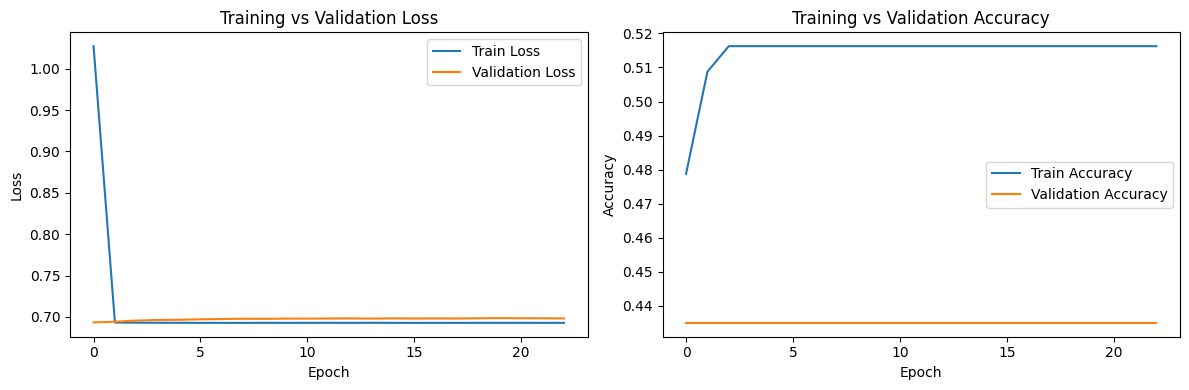

400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5163 - loss: 0.6928 - val_accuracy: 0.4350 - val_loss: 0.6982
Epoch 24/100


KeyboardInterrupt: 

In [ ]:
# -------------------
# Model Architecture
# -------------------
model = models.Sequential([
    # Input 96x96 Grayscale (1 channel).
    layers.Input(shape=(96, 96, 1)),
    layers.Rescaling(1./255),
    
    # ADDED: strides=(2, 2)
    # This reduces the activation map from 94x94 to 47x47.
    layers.Conv2D(16, (3, 3), strides=(2, 2), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.GlobalAveragePooling2D(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

early_stop = EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        start_from_epoch=20,
        restore_best_weights=True
    )

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------
# Train with Live Plot
# -------------------
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop, LivePlot()]
)

# -------------------
# Save
# -------------------
model.save("left_right_model.keras")

In [ ]:
import tensorflow as tf

# 1. Define the path to your saved model
model_path = "left_right_model.keras"

# 2. Load the model
model = keras.models.load_model(model_path)

# 3. Verify it loaded correctly by printing the architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,037 (62.65 KB)

 Trainable params: 5,345 (20.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,692 (41.77 KB)

Applying Grad-CAM to layer: conv2d_5


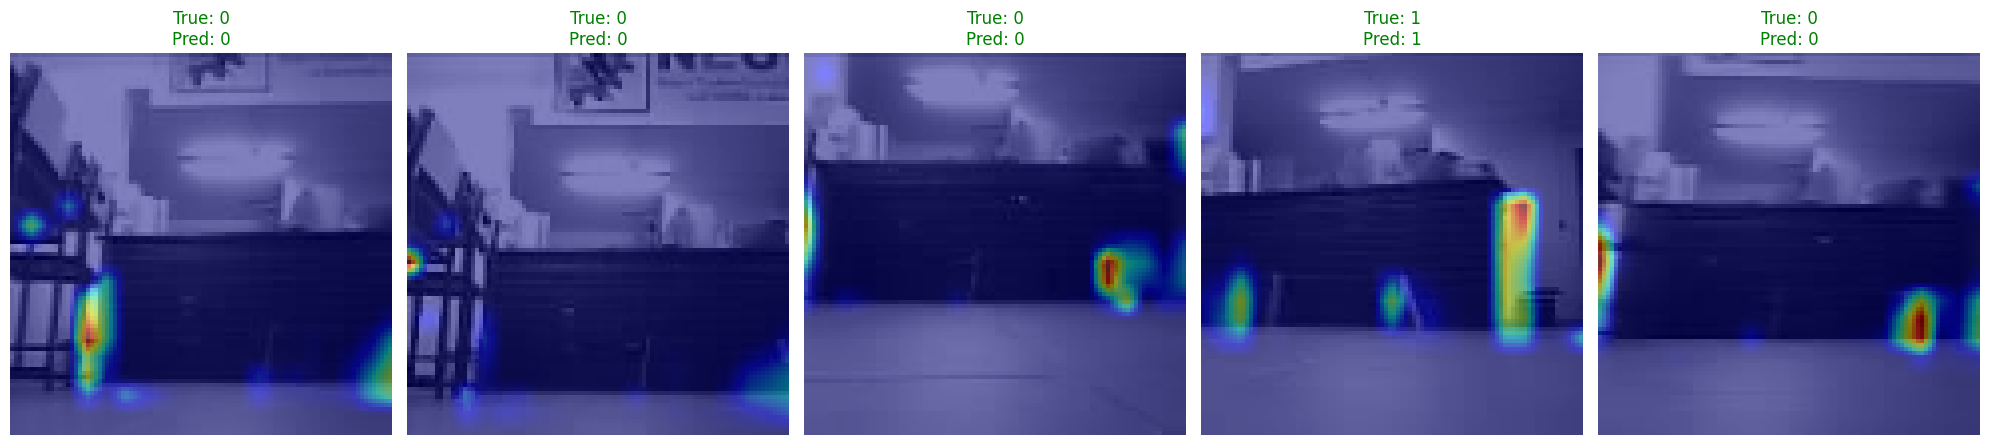

In [ ]:
import numpy as np
import matplotlib.cm as cm
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import BinaryScore




# ----------------------------------------
# 2. Extract Layer and Sample Images
# ----------------------------------------

# Automatically find the name of the last Conv2D layer in your Sequential model
last_conv_layer = [layer for layer in model.layers if isinstance(layer, layers.Conv2D)][-1]
last_conv_layer_name = last_conv_layer.name
print(f"Applying Grad-CAM to layer: {last_conv_layer_name}")

# Combine train and val datasets, unbatch them, and shuffle heavily to get random samples
full_ds = train_ds.concatenate(val_ds)
random_images_ds = full_ds.unbatch().shuffle(500).take(5)

# ----------------------------------------
# 3. Generate and Plot
# ----------------------------------------
def model_modifier(m):
    m.layers[-1].activation = tf.keras.activations.linear

# Initialize Gradcam
gradcam = Gradcam(model, model_modifier=model_modifier, clone=True)
score = BinaryScore(1.0)

plt.figure(figsize=(20, 5))

for i, (img, label) in enumerate(random_images_ds):
    img_array = tf.expand_dims(img, axis=0) 
    
    # Generate heatmap
    cam = gradcam(score, img_array, penultimate_layer=-1) 

    # Get raw prediction and convert to binary (0 or 1)
    pred_val = model.predict(img_array, verbose=0)[0][0]
    pred_binary = 1 if pred_val > 0.5 else 0
    true_binary = int(label)
    
    # Plotting
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img.numpy(), cmap='gray') 
    plt.imshow(cam[0], alpha=0.5, cmap='jet') 
    
    # Simple binary title
    title_color = 'green' if pred_binary == true_binary else 'red'
    plt.title(f"True: {true_binary}\nPred: {pred_binary}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import socket
import io
import time
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
MODEL_PATH = "left_right_model.keras" 
UDP_PORT = 5005
TCP_PORT = 80
TARGET_CAPTURES = 5
IMG_SIZE = 96

def read_until(sock_file, delimiter):
    buf = bytearray()
    while True:
        c = sock_file.read(1)
        if not c:
            return bytes(buf)
        buf.extend(c)
        if buf.endswith(delimiter):
            return bytes(buf)

def discover_esp32():
    print("[NETWORK] Listening for ESP32 broadcast...")
    udp_sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    udp_sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    udp_sock.bind(("", UDP_PORT))
    
    while True:
        data, addr = udp_sock.recvfrom(1024)
        if b"ESP32_CAM" in data:
            print(f"[NETWORK] Found ESP32 at {addr[0]}")
            udp_sock.close()
            return addr[0]

def capture_image(tcp_sock, sock_file):
    try:
        tcp_sock.sendall(b'C')
        
        raw_response = read_until(sock_file, b'<START>')
        if not raw_response.endswith(b'<START>'):
            return None
            
        length_str = read_until(sock_file, b',')[:-1].decode('utf-8')
        length = int(length_str)
        
        # IMPORTANTE: O ESP32 envia exatamente 9216 bytes (96*96)
        image_data = sock_file.read(length)
        
        end_tag = sock_file.read(5)
        if end_tag != b'<END>':
            print("[ERROR] Corrupt frame.")
            return None
            
        return image_data
    except Exception as e:
        print(f"[ERROR] Communication failed: {e}")
        return None

def process_and_predict(image_data, model):
    # 1. Transformar bytes RAW em imagem PIL (Grayscale 'L')
    img = Image.frombytes('L', (IMG_SIZE, IMG_SIZE), image_data)
    
    # 2. Converter para array
    # FIX: Removed the / 255.0 because your model already has a Rescaling(1./255) layer!
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=(0, -1)) # Shape (1, 96, 96, 1)
    
    # 3. Predict
    prediction_array = model.predict(img_array, verbose=0)
    
    # Get the raw sigmoid score
    pred_score = prediction_array[0][0]
    
    # Threshold at 0.5 to determine the class (1 = Direita, 0 = Esquerda)
    pred_class = 1 if pred_score > 0.5 else 0
        
    return img, pred_score, pred_class

def main():
    print("[SYSTEM] Loading model...")
    model = tf.keras.models.load_model(MODEL_PATH)
    
    esp_ip = discover_esp32()
    tcp_sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    tcp_sock.connect((esp_ip, TCP_PORT))
    sock_file = tcp_sock.makefile('rb')
    
    captured_images = []
    predictions = []
    classes = []
    
    print(f"\n[SYSTEM] Capturing {TARGET_CAPTURES} images...\n")
    
    while len(captured_images) < TARGET_CAPTURES:
        img_data = capture_image(tcp_sock, sock_file)
        
        if img_data:
            try:
                img_obj, pred_score, pred_class = process_and_predict(img_data, model)
                captured_images.append(img_obj)
                predictions.append(pred_score)
                classes.append(pred_class)
                
                # Print the classification to terminal
                direction = "Direita" if pred_class == 1 else "Esquerda"
                print(f"Captured {len(captured_images)} - Class: {pred_class} ({direction}) | Score: {pred_score:.4f}")
            except Exception as e:
                print(f"Error processing: {e}")
        
        time.sleep(0.1)
        
    sock_file.close()
    tcp_sock.close()

    # Visualização
    fig, axes = plt.subplots(1, TARGET_CAPTURES, figsize=(15, 4))
    for i in range(TARGET_CAPTURES):
        axes[i].imshow(captured_images[i], cmap='gray')
        
        # Color coding: Green for Right (1), Blue for Left (0)
        # (You can change these colors to whatever makes sense for your use case)
        color = 'green' if classes[i] == 1 else 'blue'
        
        # Display Class and Score just like the Grad-CAM cell
        title_text = f"Pred: {classes[i]}\nScore: {predictions[i]:.4f}"
        axes[i].set_title(title_text, color=color)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

[SYSTEM] Loading model...
[NETWORK] Listening for ESP32 broadcast...


# 1 - Direita | 0 - Esquerda

In [ ]:
import tensorflow as tf
import numpy as np

# 1. Load your Keras model
model = tf.keras.models.load_model('left_right_model.keras')

# 2. Create a representative dataset generator
# This is REQUIRED for full integer quantization. It feeds ~100 images
# to the converter to calibrate the int8 activation ranges.
def representative_data_gen():
    # Take 100 images from the training dataset
    for input_value, _ in train_ds.unbatch().batch(1).take(100):
        yield [input_value]

# 3. Convert to TensorFlow Lite Full Integer
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Enforce full INT8 quantization for all ops
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8   # Requires int8 input on the ESP32
converter.inference_output_type = tf.int8  # Outputs int8 prediction
tflite_model = converter.convert()

# 4. Save the C array to a header file
def hex_to_c_array(hex_data, var_name):
    c_str = f"const unsigned char {var_name}[] = {{\n"
    hex_array = [f"0x{hex_data[i:i+1].hex()}" for i in range(0, len(hex_data), 1)]
    for i in range(0, len(hex_array), 12):
        c_str += "  " + ", ".join(hex_array[i:i+12]) + ",\n"
    c_str += "};\n"
    c_str += f"const unsigned int {var_name}_len = {len(hex_data)};\n"
    return c_str

with open("model.h", "w") as f:
    f.write(hex_to_c_array(tflite_model, "model_data"))

print(f"Successfully generated model.h! Size is roughly {len(tflite_model) / 1024:.2f} KB.")

INFO:tensorflow:Assets written to: C:\Users\RAFAEL~1\AppData\Local\Temp\tmp8mmh4dxl\assets


INFO:tensorflow:Assets written to: C:\Users\RAFAEL~1\AppData\Local\Temp\tmp8mmh4dxl\assets


Saved artifact at 'C:\Users\RAFAEL~1\AppData\Local\Temp\tmp8mmh4dxl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2468025360144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2468028915856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2468028915664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2468028916240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2468028916048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2468028920080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2468028911632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2468027397712: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\Rafael Antunes\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Successfully generated model.h! Size is roughly 10.66 KB.


In [ ]:
import tensorflow as tf

# 1. Load model
model = tf.keras.models.load_model('left_right_model.keras')

# 2. Convert to TFLite (Default is Float32)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# We remove optimizations and target_spec to stay in Float32
tflite_model = converter.convert()

# 3. Save to C array
def hex_to_c_array(hex_data, var_name):
    c_str = f"const unsigned char {var_name}[] = {{\n"
    hex_array = [f"0x{hex_data[i:i+1].hex()}" for i in range(0, len(hex_data), 1)]
    for i in range(0, len(hex_array), 12):
        c_str += "  " + ", ".join(hex_array[i:i+12]) + ",\n"
    c_str += "};\n"
    c_str += f"const unsigned int {var_name}_len = {len(hex_data)};\n"
    return c_str

with open("model.h", "w") as f:
    f.write(hex_to_c_array(tflite_model, "model_data"))

print(f"Float32 Model Size: {len(tflite_model) / 1024:.2f} KB.")

INFO:tensorflow:Assets written to: C:\Users\RAFAEL~1\AppData\Local\Temp\tmptiethc93\assets


INFO:tensorflow:Assets written to: C:\Users\RAFAEL~1\AppData\Local\Temp\tmptiethc93\assets


Saved artifact at 'C:\Users\RAFAEL~1\AppData\Local\Temp\tmptiethc93'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1929353091728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1929549190672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1929326263568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1929326260304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1929326251856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1929326258960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1929326249552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1929326249360: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 Model Size: 24.23 KB.
